Regimes used:
sum_gt_1 0.85 0.35 sum = 1.2
sum_eq_1_a 0.75 0.25 sum = 1.0
sum_eq_1_b 0.5 0.5 sum = 1.0
sum_lt_1 0.18 0.71 sum = 0.8899999999999999
both_small_H 0.08 0.08 sum = 0.16
both_large_H 0.92 0.92 sum = 1.84


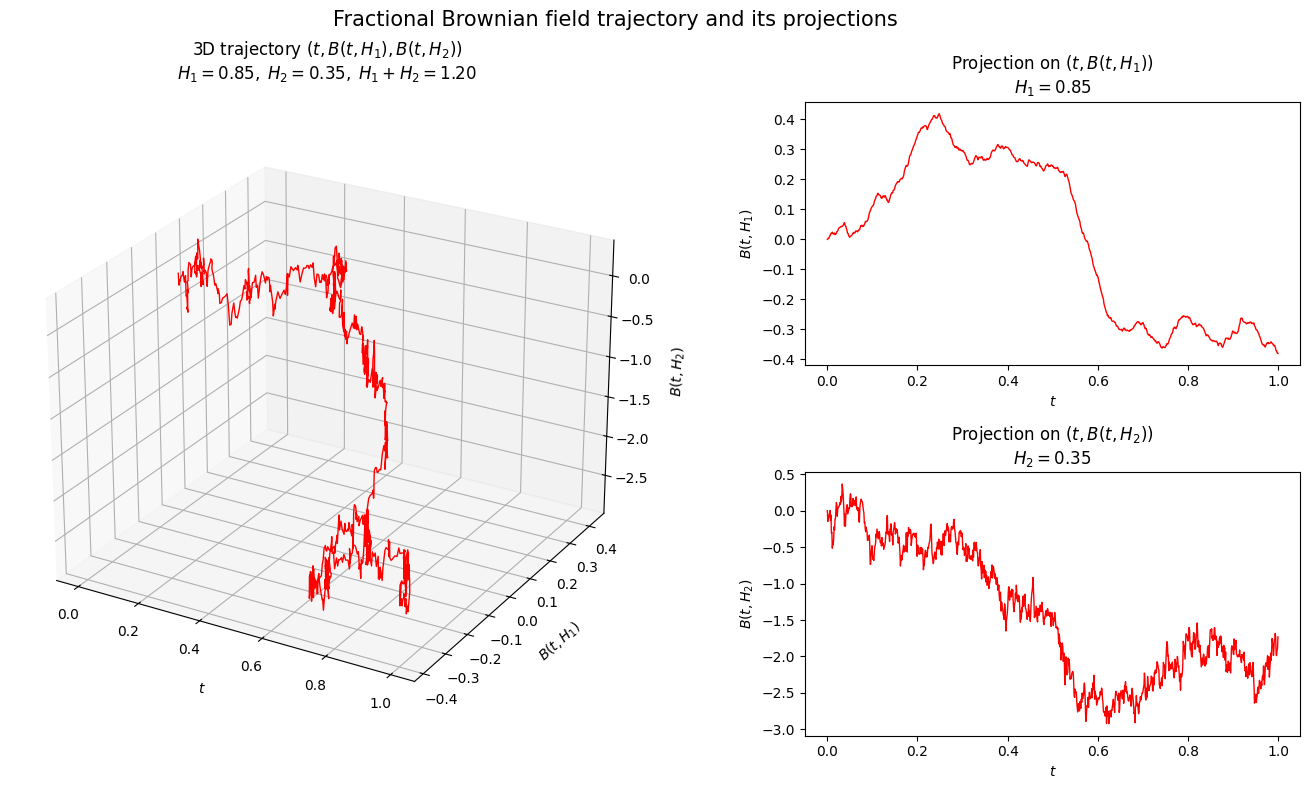

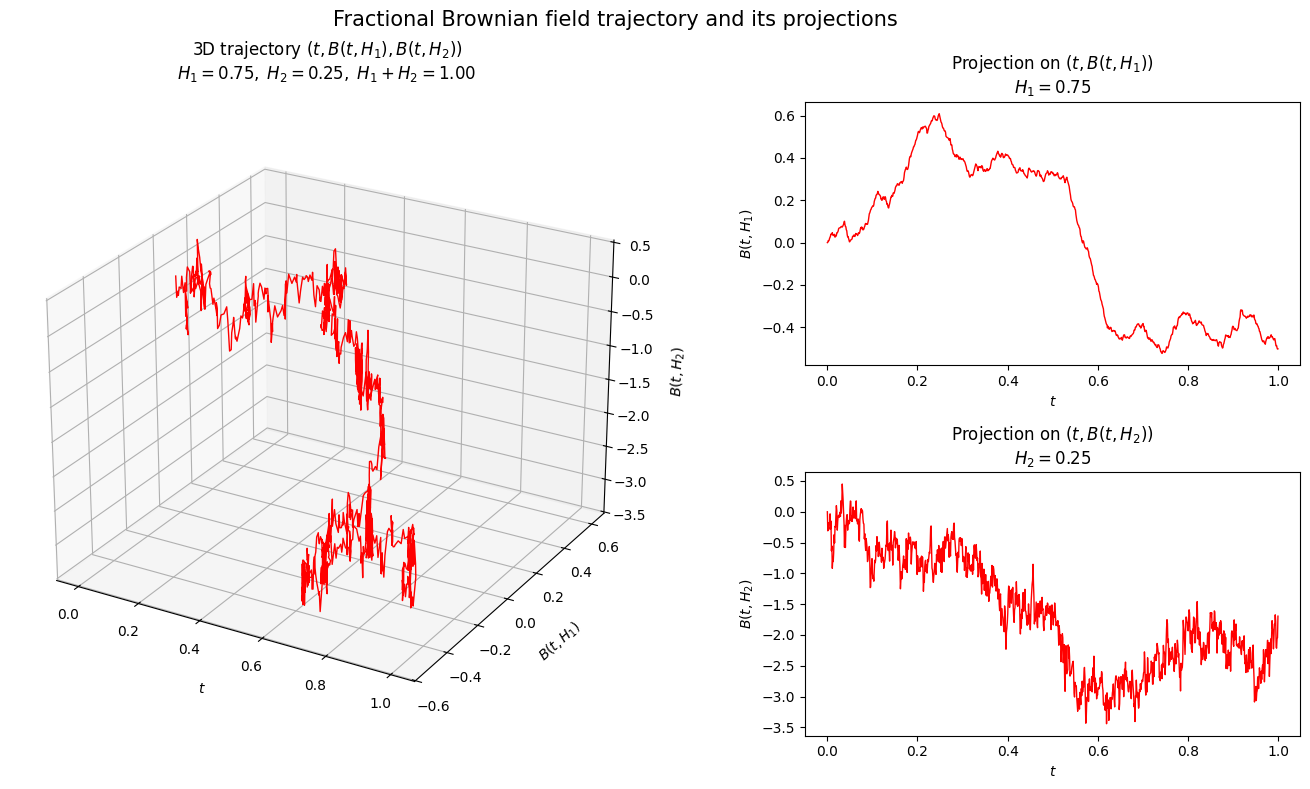

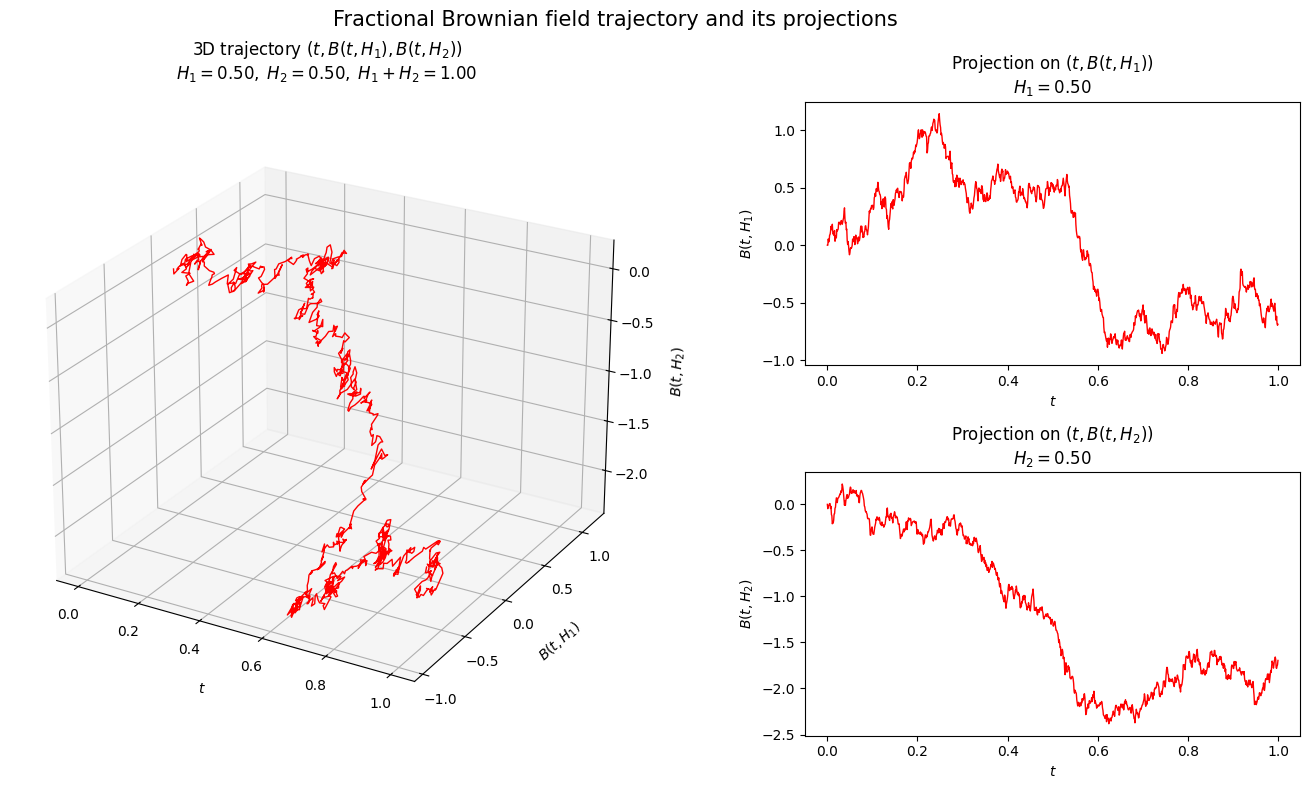

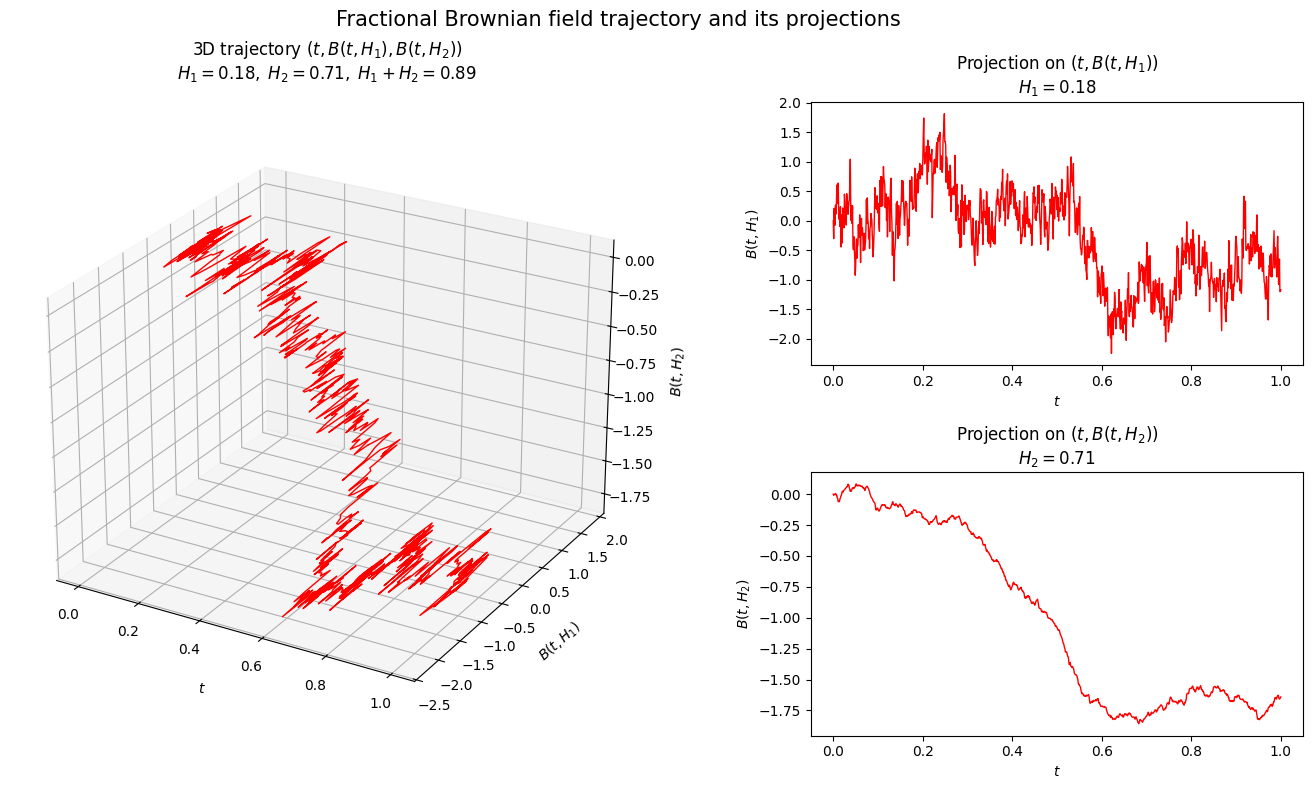

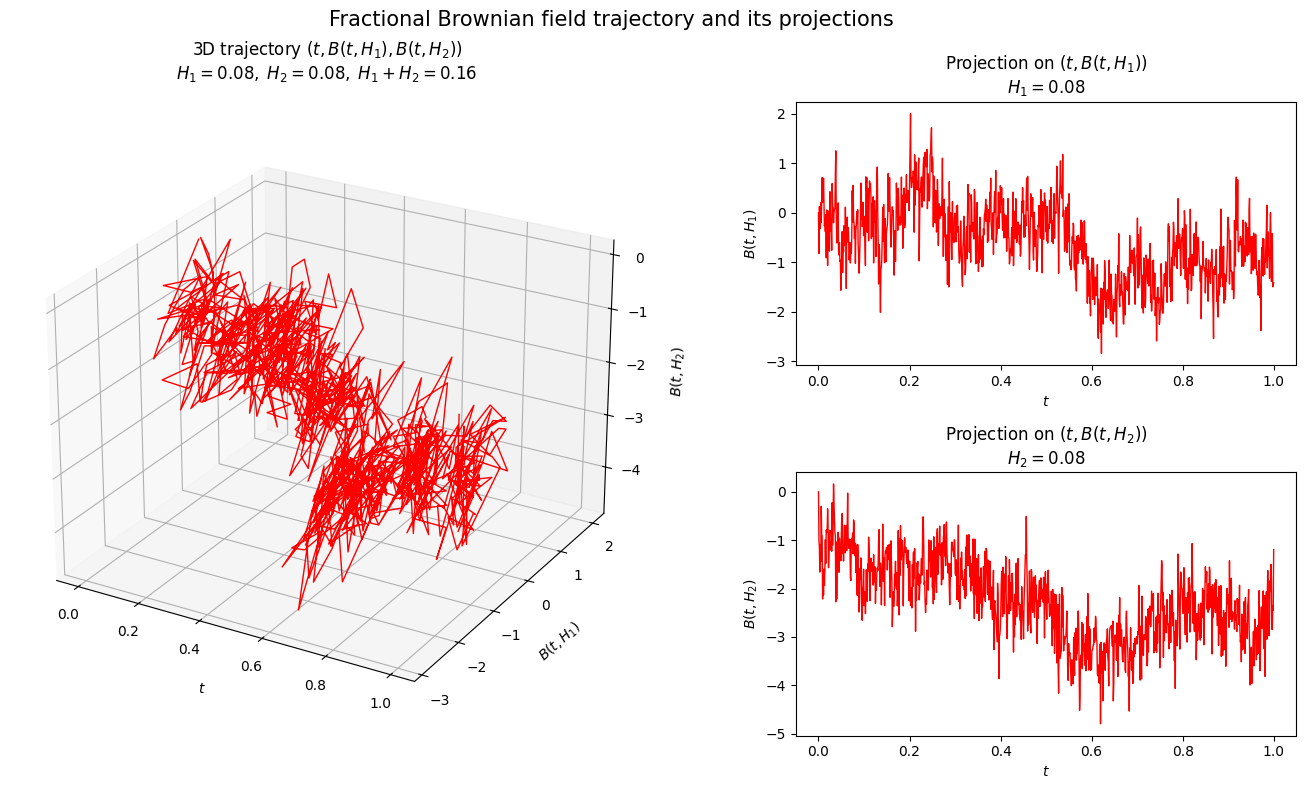

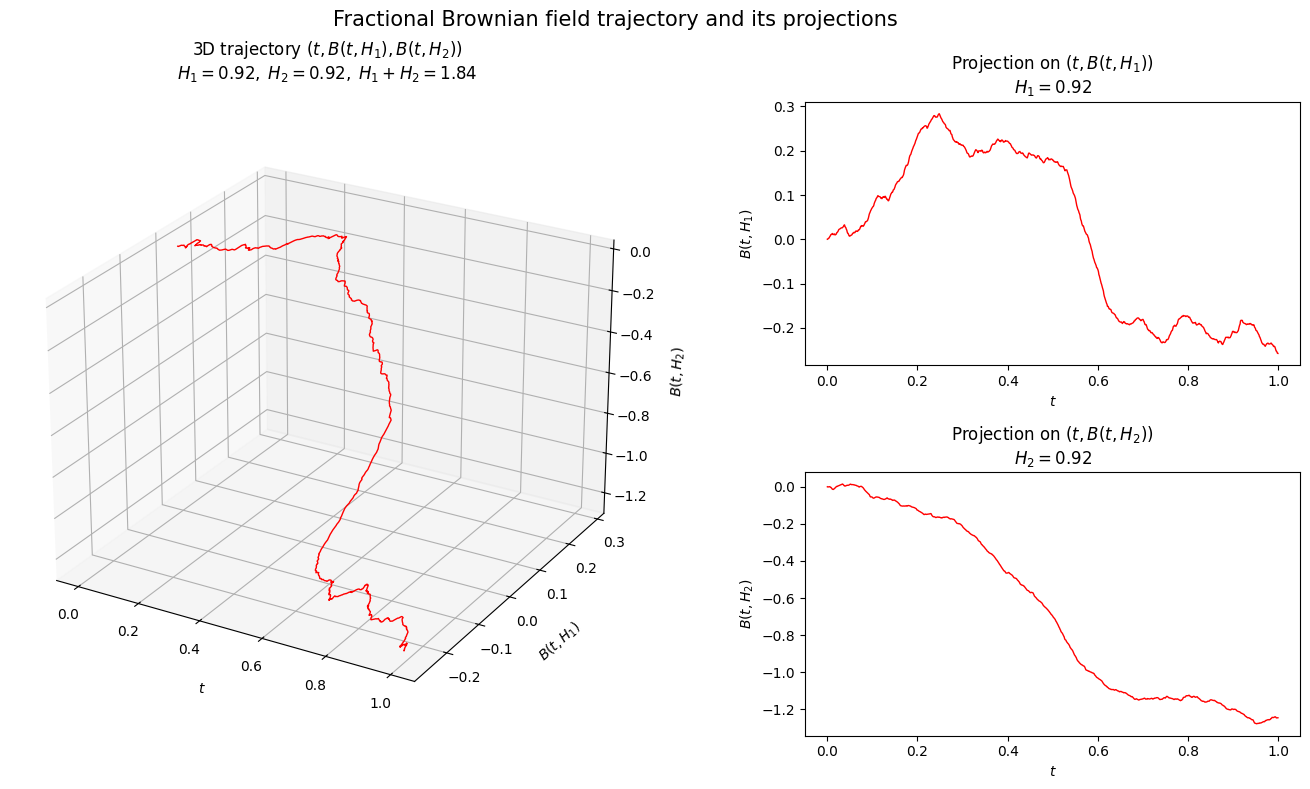


Combined figures saved in: C:\Users\14794\Desktop\Longterm memory\FBF_combined_plots


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from ractional_Brownian_Field_main import RandomFieldSimulator


# Sample H pairs
# ============================================================

def sample_H_pair_by_sum(S, rng, r=None, r_low=0.2, r_high=0.8, eps=0.05):

    for _ in range(10000):

        rr = r if r is not None else rng.uniform(r_low, r_high)

        H1 = rr * S
        H2 = (1-rr) * S

        if eps < H1 < 1-eps and eps < H2 < 1-eps:
            return float(H1), float(H2)

    raise RuntimeError("Cannot generate H pair")


def make_regimes(delta=0.2, seed=123):

    rng = np.random.default_rng(seed)

    H1_gt,H2_gt=0.85,0.35
    H1_eq_a,H2_eq_a = sample_H_pair_by_sum(1,rng,r=0.75)
    H1_eq_b,H2_eq_b = sample_H_pair_by_sum(1,rng,r=0.5)
    H1_lt,H2_lt=0.18,0.71

    regimes = [

        ("sum_gt_1",H1_gt,H2_gt),
        ("sum_eq_1_a",H1_eq_a,H2_eq_a),
        ("sum_eq_1_b",H1_eq_b,H2_eq_b),
        ("sum_lt_1",H1_lt,H2_lt),

        ("both_small_H",0.08,0.08),
        ("both_large_H",0.92,0.92)

    ]

    return regimes


# Simulate two paths
# ============================================================

def simulate_two_slices(H1, H2,
                        sample_size=1000,
                        tmax=1,
                        FBM_cov_md=1,
                        rf_factor=0.7,
                        seed=123):

    sim1 = RandomFieldSimulator(sample_size, H1, 0, tmax, FBM_cov_md, rf_factor)
    sim2 = RandomFieldSimulator(sample_size, H2, 0, tmax, FBM_cov_md, rf_factor)

    try:
        x1 = sim1.get_self_similar_process(seed=seed+1)
    except:
        x1 = sim1.get_self_similar_process()

    try:
        x2 = sim2.get_self_similar_process(seed=seed+2)
    except:
        x2 = sim2.get_self_similar_process()

    x1 = np.asarray(x1, float)
    x2 = np.asarray(x2, float)

    t = np.linspace(0, tmax, sample_size)

    return t, x1, x2


# Combined figure: 3D + 2 projections
# ============================================================

def plot_combined_figure(t, x1, x2, H1, H2, title, outpath=None):

    fig = plt.figure(figsize=(14, 8))
    gs = GridSpec(2, 2, width_ratios=[1.6, 1], height_ratios=[1, 1], figure=fig)

    
    # Left: 3D trajectory
    
    ax3d = fig.add_subplot(gs[:, 0], projection="3d")
    ax3d.plot(t, x1, x2, linewidth=1, color="red")

    ax3d.set_xlabel(r"$t$", labelpad=10)
    ax3d.set_ylabel(r"$B(t,H_1)$", labelpad=10)
    ax3d.set_zlabel(r"$B(t,H_2)$", labelpad=10)

    ax3d.set_title(
        rf"3D trajectory $(t, B(t,H_1), B(t,H_2))$"
        "\n"
        rf"$H_1={H1:.2f},\; H_2={H2:.2f},\; H_1+H_2={H1+H2:.2f}$",
        pad=16
    )

    ax3d.view_init(elev=25, azim=-60)

    
    # Right top: projection (t, B(t,H1))
    
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(t, x1, linewidth=1, color="red")
    ax1.set_xlabel(r"$t$")
    ax1.set_ylabel(r"$B(t,H_1)$")
    ax1.set_title(
        rf"Projection on $(t, B(t,H_1))$"
        "\n"
        rf"$H_1={H1:.2f}$"
    )

    
    # Right bottom: projection (t, B(t,H2))
    
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.plot(t, x2, linewidth=1, color="red")
    ax2.set_xlabel(r"$t$")
    ax2.set_ylabel(r"$B(t,H_2)$")
    ax2.set_title(
        rf"Projection on $(t, B(t,H_2))$"
        "\n"
        rf"$H_2={H2:.2f}$"
    )

    fig.suptitle(title, fontsize=15, y=0.98)

    plt.tight_layout()

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches="tight", pad_inches=0.2)

    plt.show()



# Main

def main():

    outdir = "FBF_combined_plots"
    os.makedirs(outdir, exist_ok=True)

    regimes = make_regimes()

    print("Regimes used:")
    for tag, H1, H2 in regimes:
        print(tag, H1, H2, "sum =", H1+H2)

    for tag, H1, H2 in regimes:

        t, x1, x2 = simulate_two_slices(H1, H2)

        outfile = os.path.join(outdir, f"{tag}_combined.png")

        plot_combined_figure(
            t, x1, x2,
            H1, H2,
            title="Fractional Brownian field trajectory and its projections",
            outpath=outfile
        )

    print("\nCombined figures saved in:", os.path.abspath(outdir))


if __name__ == "__main__":
    main()